# Notebook 01.2: MobileNetV2 + 5-Fold Ensemble + Cosine LR + Multi-Scale TTA

Takes notebook 01's best recipe (MobileNetV2 fine-tune + augmentation) and wraps it in **5-fold stratified cross-validation** with a **cosine LR schedule** and **multi-scale TTA** at inference.

### Why this helps
- **Variance reduction**: averaging 5 models trained on slightly different data splits removes noise from any single split.
- **Better threshold**: Youden's-J is picked from 1,578 out-of-fold predictions instead of just 316 val samples — much more stable.
- **Cosine LR decay**: learning rate anneals smoothly to ~0 over the fold — usually squeezes ~0.5-1% AUROC out of the same compute budget.
- **Multi-scale TTA**: inference at 3 scales (256/320/384) × 2 flips = 6-view ensemble per test image. Free at training time.

### What runs where
- Per fold: `build_finetune()` + 25 epochs (cosine schedule) with augmentation. Save best-val checkpoint.
- Per fold: predict on the 176 test images with multi-scale + hflip TTA.
- End: average the 5 test prob vectors → one submission CSV.

### Runtime expectation (IMG_SIZE=256, batch=16, MPS)
- 25 epochs × 5 folds ≈ **125 training epochs** ≈ **~25 min**.
- Multi-scale TTA inference: minor overhead.

---
## Step 1: Imports

In [1]:
import copy
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as T
from PIL import Image
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import DataLoader, Dataset
from torchvision.models import MobileNet_V2_Weights, mobilenet_v2
from tqdm.auto import tqdm

print("Imports OK")

Imports OK


/Users/jasonsmith/Desktop/medical-cv-hackathon/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 2: Reproducibility + Device

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Device: {device}")

Device: mps


## Step 3: Configuration

In [3]:
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TRAIN_CSV = REPO / "data" / "train_val" / "train_val.csv"
TRAIN_IMG_DIR = REPO / "data" / "train_val" / "images"
TEST_IMG_DIR = REPO / "data" / "test_images"
PRED_DIR = REPO / "outputs" / "predictions"
CKPT_DIR = REPO / "outputs" / "checkpoints"
PRED_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 256
BATCH_SIZE = 16
NUM_WORKERS = 0         # Jupyter on macOS requires 0
N_FOLDS = 5
EPOCHS_PER_FOLD = 25
TTA_SCALES = [IMG_SIZE, IMG_SIZE + 64, IMG_SIZE + 128]  # [256, 320, 384]

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print(f"IMG_SIZE  : {IMG_SIZE}")
print(f"BATCH_SIZE: {BATCH_SIZE}")
print(f"Folds     : {N_FOLDS}")
print(f"Epochs/fd : {EPOCHS_PER_FOLD}")
print(f"TTA scales: {TTA_SCALES}")

IMG_SIZE  : 256
BATCH_SIZE: 16
Folds     : 5
Epochs/fd : 25
TTA scales: [256, 320, 384]


## Step 4: Load labels

In [4]:
df = pd.read_csv(TRAIN_CSV)
df = df.rename(columns={
    "Image Index": "image_file",
    "Patient Age": "age",
    "Patient Sex": "sex",
    "Finding Labels": "finding",
})
df["label"] = (df["finding"] == "Cardiomegaly").astype(int)
df = df.reset_index(drop=True)

print(df["finding"].value_counts())
print(f"Positive rate: {df['label'].mean():.3f}")
print(f"Total        : {len(df)}")

finding
No Finding      858
Cardiomegaly    720
Name: count, dtype: int64
Positive rate: 0.456
Total        : 1578


## Step 5: Dataset class + transforms

In [5]:
class CardiomegalyDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, return_label=True):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.return_label = return_label

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.img_dir / row["image_file"])
        if img.mode != "RGB":
            img = img.convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        if not self.return_label:
            return img, row["image_file"]
        return img, torch.tensor(row["label"], dtype=torch.float32)


def build_transform(img_size, augment=False):
    ops = [T.Resize((img_size, img_size))]
    if augment:
        ops += [
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=5),
            T.ColorJitter(brightness=0.1, contrast=0.1),
        ]
    ops += [T.ToTensor(), T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)]
    return T.Compose(ops)

## Step 6: Metrics, model factory, train/eval loops

In [6]:
def sens_spec(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true); y_prob = np.asarray(y_prob)
    pred = (y_prob >= threshold).astype(int)
    tp = int(((pred == 1) & (y_true == 1)).sum())
    tn = int(((pred == 0) & (y_true == 0)).sum())
    fp = int(((pred == 1) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    return sens, spec

def datathon_score(auroc, sens, spec):
    return 0.5 * auroc + 0.25 * sens + 0.25 * spec

def best_threshold(y_true, y_prob):
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    return float(thr[np.argmax(tpr - fpr)])

def build_finetune():
    model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
    for p in model.parameters():
        p.requires_grad = False
    for p in model.features[14:].parameters():
        p.requires_grad = True
    model.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(1280, 1))
    return model

@torch.no_grad()
def predict_probs(model, loader, device, tta_scales=None, tta_hflip=False):
    """Predict probabilities with optional multi-scale + hflip TTA.

    tta_scales: list of ints. If None, run images at their loader size.
                Otherwise, resize each batch with bilinear interpolation to each
                scale and average the resulting probabilities.
    tta_hflip : if True, also run a horizontally-flipped pass at every scale.
    """
    model.eval()
    out = []
    for batch in loader:
        imgs = batch[0].to(device)
        scales = tta_scales if tta_scales else [imgs.shape[-1]]
        prob_sum = torch.zeros(imgs.size(0), device=device)
        n_views = 0
        for s in scales:
            view = imgs if s == imgs.shape[-1] else F.interpolate(
                imgs, size=(s, s), mode="bilinear", align_corners=False
            )
            prob_sum = prob_sum + torch.sigmoid(model(view).squeeze(1))
            n_views += 1
            if tta_hflip:
                prob_sum = prob_sum + torch.sigmoid(
                    model(torch.flip(view, dims=[3])).squeeze(1)
                )
                n_views += 1
        out.append((prob_sum / n_views).cpu().numpy())
    return np.concatenate(out)

def train_one_fold(model, train_loader, val_loader, optimizer, scheduler, epochs, device, tag):
    criterion = nn.BCEWithLogitsLoss()
    best = {"score": -1.0, "auroc": -1.0, "state": None, "epoch": 0}
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        model.train()
        total = 0.0
        pbar = tqdm(train_loader, leave=False, desc=f"{tag} ep{epoch}")
        for imgs, labels in pbar:
            imgs = imgs.to(device); labels = labels.to(device)
            optimizer.zero_grad()
            logits = model(imgs).squeeze(1)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            total += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.3f}")
        # fast per-epoch val (no TTA) for best-checkpoint selection
        val_probs = predict_probs(model, val_loader, device)
        val_labels = np.concatenate([lbl.numpy() for _, lbl in val_loader])
        auroc = roc_auc_score(val_labels, val_probs)
        thr = best_threshold(val_labels, val_probs)
        sens, spec = sens_spec(val_labels, val_probs, threshold=thr)
        score = datathon_score(auroc, sens, spec)
        scheduler.step()
        lr_now = optimizer.param_groups[-1]["lr"]
        dt = time.time() - t0
        star = ""
        if score > best["score"]:
            best = {"score": score, "auroc": auroc, "sens": sens, "spec": spec,
                    "thr": thr, "state": copy.deepcopy(model.state_dict()), "epoch": epoch}
            star = " ★"
            torch.save(model.state_dict(), CKPT_DIR / f"{tag}_best.pt")
        print(f"  [{tag}] ep {epoch:02d}  loss {total/len(train_loader):.4f}  "
              f"AUROC {auroc:.4f}  sens {sens:.3f}  spec {spec:.3f}  "
              f"score {score:.4f}  lr {lr_now:.2e}  ({dt:.1f}s){star}")
    model.load_state_dict(best["state"])
    return model, best

---
## Step 7: Set up K-Fold + Test Loader

The test loader is built once — every fold's model will predict on the same test images.

In [7]:
test_files = sorted(p.name for p in TEST_IMG_DIR.iterdir() if p.suffix.lower() == ".png")
test_df = pd.DataFrame({"image_file": test_files, "label": 0})
test_tf = build_transform(IMG_SIZE, augment=False)
test_ds = CardiomegalyDataset(test_df, TEST_IMG_DIR, transform=test_tf, return_label=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
print(f"Test images: {len(test_ds)}")

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
splits = list(skf.split(df.index, df["label"]))
for i, (tr, va) in enumerate(splits):
    pr = df.iloc[va]["label"].mean()
    print(f"Fold {i+1}: train={len(tr)}  val={len(va)}  val pos rate={pr:.3f}")

Test images: 176
Fold 1: train=1262  val=316  val pos rate=0.456
Fold 2: train=1262  val=316  val pos rate=0.456
Fold 3: train=1262  val=316  val pos rate=0.456
Fold 4: train=1263  val=315  val pos rate=0.457
Fold 5: train=1263  val=315  val pos rate=0.457


---
## Step 8: Train all folds + collect OOF + test predictions

For each fold we: (a) train a fresh fine-tuned MobileNetV2 for 25 epochs with a cosine LR schedule, (b) record its OOF predictions using multi-scale + hflip TTA, (c) predict on the test set with the same TTA. Test predictions get averaged across folds at the end.

In [8]:
oof_probs = np.zeros(len(df))                        # one entry per training image
test_fold_probs = np.zeros((N_FOLDS, len(test_ds)))  # per-fold test preds
fold_val_aurocs = []

for fold_idx, (train_idx, val_idx) in enumerate(splits):
    fold_num = fold_idx + 1
    tag = f"kfold{fold_num}of{N_FOLDS}"
    print(f"\n{'='*60}\nFOLD {fold_num}/{N_FOLDS}\n{'='*60}")

    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)

    train_ds = CardiomegalyDataset(train_df, TRAIN_IMG_DIR, transform=build_transform(IMG_SIZE, augment=True))
    val_ds = CardiomegalyDataset(val_df, TRAIN_IMG_DIR, transform=build_transform(IMG_SIZE, augment=False))
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    model = build_finetune().to(device)
    optimizer = optim.AdamW([
        {"params": model.features[14:].parameters(), "lr": 1e-5},
        {"params": model.classifier.parameters(), "lr": 1e-4},
    ])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_PER_FOLD)
    model, best = train_one_fold(model, train_loader, val_loader, optimizer, scheduler, EPOCHS_PER_FOLD, device, tag)
    fold_val_aurocs.append(best["auroc"])

    # OOF preds for this fold's validation set — multi-scale + hflip TTA
    oof_probs[val_idx] = predict_probs(model, val_loader, device, tta_scales=TTA_SCALES, tta_hflip=True)

    # Test preds for this fold's model — same TTA
    test_fold_probs[fold_idx] = predict_probs(model, test_loader, device, tta_scales=TTA_SCALES, tta_hflip=True)

    # Free GPU memory before next fold
    del model
    if device.type == "mps":
        torch.mps.empty_cache()

print(f"\nPer-fold best val AUROC: {[round(a, 4) for a in fold_val_aurocs]}")
print(f"Mean fold val AUROC    : {np.mean(fold_val_aurocs):.4f}")


FOLD 1/5


  [kfold1of5] ep 01  loss 0.6640  AUROC 0.7990  sens 0.660  spec 0.837  score 0.7737  lr 9.96e-05  (29.5s) ★


  [kfold1of5] ep 02  loss 0.5991  AUROC 0.8215  sens 0.660  spec 0.878  score 0.7952  lr 9.84e-05  (27.9s) ★


  [kfold1of5] ep 03  loss 0.5704  AUROC 0.8393  sens 0.701  spec 0.872  score 0.8130  lr 9.65e-05  (27.8s) ★


  [kfold1of5] ep 04  loss 0.5316  AUROC 0.8511  sens 0.729  spec 0.878  score 0.8273  lr 9.38e-05  (27.8s) ★


...

  [kfold5of5] ep 21  loss 0.3815  AUROC 0.8766  sens 0.799  spec 0.813  score 0.8412  lr 6.18e-06  (27.3s) ★


  [kfold5of5] ep 22  loss 0.3827  AUROC 0.8773  sens 0.826  spec 0.784  score 0.8412  lr 3.51e-06  (27.4s)


  [kfold5of5] ep 23  loss 0.3688  AUROC 0.8740  sens 0.792  spec 0.813  score 0.8381  lr 1.57e-06  (27.3s)


  [kfold5of5] ep 24  loss 0.3858  AUROC 0.8775  sens 0.819  spec 0.795  score 0.8424  lr 3.94e-07  (27.3s) ★


  [kfold5of5] ep 25  loss 0.3730  AUROC 0.8763  sens 0.833  spec 0.784  score 0.8424  lr 0.00e+00  (27.3s)

Per-fold best val AUROC: [0.8834, 0.8676, 0.8666, 0.8676, 0.8775]
Mean fold val AUROC    : 0.8725


---
## Step 9: OOF metrics + best threshold

Now we have an out-of-fold probability for every one of the 1,578 training images. Use these to pick a robust Youden's-J threshold and see a realistic estimate of leaderboard performance.

OOF AUROC       : 0.8696
Best threshold  : 0.420
OOF Sensitivity : 0.8500
OOF Specificity : 0.7471
OOF datathon    : 0.8341


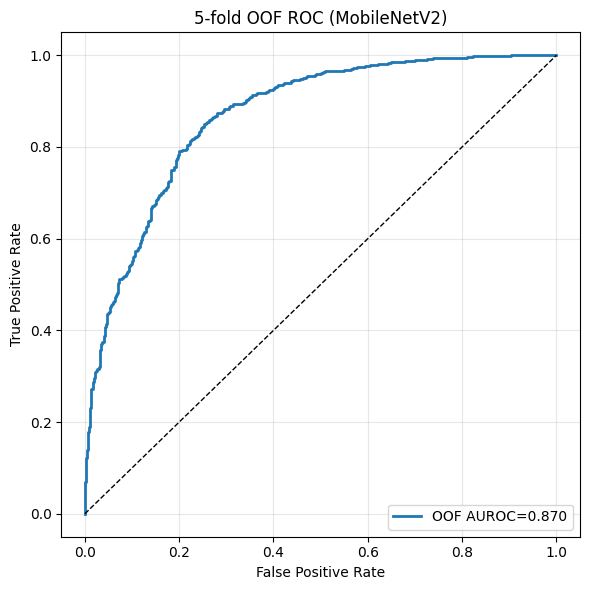

In [9]:
y_true = df["label"].values
oof_auroc = roc_auc_score(y_true, oof_probs)
oof_thr = best_threshold(y_true, oof_probs)
oof_sens, oof_spec = sens_spec(y_true, oof_probs, threshold=oof_thr)
oof_score = datathon_score(oof_auroc, oof_sens, oof_spec)

print(f"OOF AUROC       : {oof_auroc:.4f}")
print(f"Best threshold  : {oof_thr:.3f}")
print(f"OOF Sensitivity : {oof_sens:.4f}")
print(f"OOF Specificity : {oof_spec:.4f}")
print(f"OOF datathon    : {oof_score:.4f}")

fpr, tpr, _ = roc_curve(y_true, oof_probs)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, lw=2, label=f"OOF AUROC={oof_auroc:.3f}")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("5-fold OOF ROC (MobileNetV2)")
plt.legend(loc="lower right"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

---
## Step 10: Ensemble the 5 test predictions + write submission

The final probability is the mean across folds. Threshold from the OOF step.

In [10]:
test_probs_mean = test_fold_probs.mean(axis=0)

sub = pd.DataFrame({"image_file": test_files, "prob": test_probs_mean})
sub["pred"] = (sub["prob"] >= oof_thr).astype(int)
sub = sub.sort_values("image_file").reset_index(drop=True)

stamp = time.strftime("%Y%m%d_%H%M")
out_path = PRED_DIR / f"submission_mobilenet_kfold_{stamp}.csv"
sub.to_csv(out_path, index=False)

np.save(PRED_DIR / f"oof_probs_mobilenet_kfold_{stamp}.npy", oof_probs)
np.save(PRED_DIR / f"test_fold_probs_mobilenet_kfold_{stamp}.npy", test_fold_probs)

print(f"Wrote {out_path}")
print(sub.head())
print(f"\nSubmission positive rate: {sub['pred'].mean():.3f}")
print(f"Training set positive rate: {df['label'].mean():.3f}")

Wrote /Users/jasonsmith/Desktop/medical-cv-hackathon/outputs/predictions/submission_mobilenet_kfold_20260420_1722.csv
       image_file      prob  pred
0  IMG_000018.png  0.638864     1
1  IMG_000021.png  0.107672     0
2  IMG_000039.png  0.536624     1
3  IMG_000044.png  0.429964     1
4  IMG_000047.png  0.454720     1

Submission positive rate: 0.483
Training set positive rate: 0.456


---
## Notes

- `oof_probs_*.npy` and `test_fold_probs_*.npy` are saved so you can later blend this notebook's ensemble with DenseNet121 / EfficientNet-B0 ensembles (multi-model ensemble = even stronger).
- If you run 02_densenet121 and 03_efficientnet_b0 in k-fold form too, a final blend is just: `final_test_probs = (test_probs_mobilenet + test_probs_densenet + test_probs_effnet) / 3`, then re-pick the threshold on the concatenated OOF predictions.